# Recurrent Neural Networks (RNNs) — Clear Introduction, Intuition, and Notation

---

## 1. What is an RNN?

A **Recurrent Neural Network (RNN)** is a neural network designed to process **sequential data** — like time series, text, speech, or any data where **order matters**.

Unlike a feedforward neural network that maps:
$$
\hat{y} = f(x)
$$
with no memory,  
an RNN has a **hidden state** that **carries information forward in time**.

---

## 2. How does an RNN work?

At each **time step $t$**, an RNN:
- Receives the **current input** $x_t$ (e.g., the current word, frame, or signal value).
- Combines it with the **previous hidden state** $h_{t-1}$ — which stores info from all previous steps.
- Produces a **new hidden state** $h_t$.
- Optionally produces an output $\hat{y}_t$ (e.g., a prediction or next word).

---

## 3. The Core Equations

The **vanilla RNN** update equations are:

$$
a_t = W_{xh} x_t + W_{hh} h_{t-1} + b_h
$$

$$
h_t = \tanh(a_t)
$$

$$
\hat{y}_t = W_{hy} h_t + b_y.
$$

---

## 4. What does each term mean?

✅ **$x_t$**  
- The input at time $t$.  
- Example: the current word encoded as a vector, or a single scalar value in a time series.

✅ **$h_{t-1}$**  
- The hidden state from the **previous time step**.  
- This acts as the **memory** of the network.

✅ **$W_{xh}$**  
- **Input-to-hidden weights**.  
- Maps the current input $x_t$ to the hidden layer’s space.

✅ **$W_{hh}$**  
- **Hidden-to-hidden recurrent weights**.  
- Maps the **previous hidden state** $h_{t-1}$ forward to influence the new state $h_t$.

✅ **$b_h$**  
- Bias term for the hidden state computation.

✅ **$a_t$**  
- The **pre-activation** (the linear combination) before applying the nonlinearity.

✅ **$\tanh$**  
- Nonlinearity.  
- Squashes the activation to $(-1, 1)$.  
- Helps the network learn complex dependencies.

✅ **$W_{hy}$**  
- **Hidden-to-output weights**.  
- Maps the hidden state $h_t$ to the final output.

✅ **$b_y$**  
- Bias term for the output.

✅ **$\hat{y}_t$**  
- The predicted output at time step $t$.

---

## 5. The hidden state is the memory

Key idea:
- $h_t$ stores **all relevant information** about the sequence up to time $t$.
- It’s computed recursively: $h_t$ depends on $h_{t-1}$, which depends on $h_{t-2}$, and so on.
- This chain is what allows the network to **remember**.

---

## 6. What does this achieve?

✅ When training, the RNN:
- Learns $W_{xh}$ → how much the **new input** affects the memory.
- Learns $W_{hh}$ → how much **past memory** persists forward.
- Learns $W_{hy}$ → how to map the hidden state to the desired output.

---

## 7. Why do we need the nonlinearity?

If we removed $\tanh$:
$$
h_t = a_t = W_{xh} x_t + W_{hh} h_{t-1} + b_h
$$

This would collapse to a **purely linear system**: you could unroll it to a single matrix times all inputs — it couldn’t learn complex patterns.

---

## 8. A tiny concrete walk-through ($T=2$)

**Suppose:**
- $h_0 = 0$ (zero initial memory)
- You have $x_1, x_2$

Then:
$$
a_1 = W_{xh} x_1 + W_{hh} h_0 + b_h
\quad \Longrightarrow \quad
h_1 = \tanh(a_1)
$$

$$
a_2 = W_{xh} x_2 + W_{hh} h_1 + b_h
\quad \Longrightarrow \quad
h_2 = \tanh(a_2)
$$

---

✅ The output at each step:
$$
\hat{y}_1 = W_{hy} h_1 + b_y, 
\quad 
\hat{y}_2 = W_{hy} h_2 + b_y.
$$

---

## 9. Summary

- The same $W_{xh}$, $W_{hh}$, $W_{hy}$ are used at **every time step**.
- This parameter sharing is what makes the model powerful and efficient.
- The sequence of states $h_t$ forms the **unrolled computational graph** you see in BPTT.

---

# RNN BPTT — Precise, Fully Unrolled Derivation (T = 2)

---

## 1. Trainable parameters

A vanilla RNN has these **trainable weights and biases**:
- $W_{xh}$: input → hidden weights
- $W_{hh}$: hidden → hidden recurrent weights
- $b_h$: bias for hidden state
- $W_{hy}$: hidden → output weights
- $b_y$: output bias

---

## 2. Forward pass for T = 2

**Inputs:**  
- $x_1$, $x_2$  
- Initial hidden $h_0$ (can be 0 or learnable)

---

**At $t=1$:**

$$
a_1 = W_{xh} x_1 + W_{hh} h_0 + b_h
$$

$$
h_1 = \tanh(a_1)
$$

$$
\hat{y}_1 = W_{hy} h_1 + b_y.
$$

---

**At $t=2$:**

$$
a_2 = W_{xh} x_2 + W_{hh} h_1 + b_h
$$

$$
h_2 = \tanh(a_2)
$$

$$
\hat{y}_2 = W_{hy} h_2 + b_y.
$$

---

## 3. Loss

At each step:

$$
L_1 = \frac{1}{2} (\hat{y}_1 - y_1)^2, \quad
L_2 = \frac{1}{2} (\hat{y}_2 - y_2)^2.
$$

Total loss:

$$
L = L_1 + L_2.
$$

---

## 4. Goal

We want:

$$
\frac{\partial L}{\partial W_{hy}}, \quad
\frac{\partial L}{\partial b_y}, \quad
\frac{\partial L}{\partial W_{xh}}, \quad
\frac{\partial L}{\partial W_{hh}}, \quad
\frac{\partial L}{\partial b_h}.
$$

---

## 5. Gradients for output weights and bias

**Output at $t$:**

$$
\hat{y}_t = W_{hy} h_t + b_y.
$$

So,

$$
\frac{\partial L_t}{\partial W_{hy}} = \frac{\partial L_t}{\partial \hat{y}_t} \frac{\partial \hat{y}_t}{\partial W_{hy}}
= (\hat{y}_t - y_t) h_t^T.
$$

Therefore,

$$
\frac{\partial L}{\partial W_{hy}} = (\hat{y}_1 - y_1) h_1^T + (\hat{y}_2 - y_2) h_2^T.
$$

Similarly,

$$
\frac{\partial L}{\partial b_y} = (\hat{y}_1 - y_1) + (\hat{y}_2 - y_2).
$$

---

## 6. Gradient for $W_{xh}$

**We see that $W_{xh}$ affects:**
- $a_1$ directly → $h_1$ → $\hat{y}_1$  
- $a_2$ directly → $h_2$ → $\hat{y}_2$  
- Plus $a_2$ also indirectly depends on $a_1$ through $h_1$.

---

### 6.1 Direct contribution

- $L_1$ path:

$$
\frac{\partial L_1}{\partial W_{xh}} = 
\frac{\partial L_1}{\partial \hat{y}_1} \cdot 
\frac{\partial \hat{y}_1}{\partial h_1} \cdot 
\frac{\partial h_1}{\partial a_1} \cdot 
\frac{\partial a_1}{\partial W_{xh}}.
$$

Each piece:

$$
\frac{\partial L_1}{\partial \hat{y}_1} = \hat{y}_1 - y_1, \quad
\frac{\partial \hat{y}_1}{\partial h_1} = W_{hy}, \quad
\frac{\partial h_1}{\partial a_1} = 1 - h_1^2, \quad
\frac{\partial a_1}{\partial W_{xh}} = x_1.
$$

So,

$$
\text{Direct for } L_1: 
\quad
(\hat{y}_1 - y_1) W_{hy} (1 - h_1^2) x_1^T.
$$

---

### 6.2 Direct for $L_2$

- $a_2$ depends directly on $W_{xh}$:

$$
\frac{\partial L_2}{\partial W_{xh}} =
\frac{\partial L_2}{\partial \hat{y}_2}
\cdot \frac{\partial \hat{y}_2}{\partial h_2}
\cdot \frac{\partial h_2}{\partial a_2}
\cdot \frac{\partial a_2}{\partial W_{xh}}.
$$

Same expansions:

$$
= (\hat{y}_2 - y_2) W_{hy} (1 - h_2^2) x_2^T.
$$

---

### 6.3 Indirect for $L_2$ through $h_1$

But $a_2$ also depends on $h_1$:

$$
a_2 = W_{xh} x_2 + W_{hh} h_1 + b_h.
$$

So there’s a path:

$$
L_2 \rightarrow \hat{y}_2 \rightarrow h_2 \rightarrow a_2 \rightarrow h_1 \rightarrow a_1 \rightarrow W_{xh}.
$$

---

The indirect piece is:

$$
\frac{\partial L_2}{\partial W_{xh}} 
= \frac{\partial L_2}{\partial \hat{y}_2} \cdot
\frac{\partial \hat{y}_2}{\partial h_2} \cdot
\frac{\partial h_2}{\partial a_2} \cdot
\frac{\partial a_2}{\partial h_1} \cdot
\frac{\partial h_1}{\partial a_1} \cdot
\frac{\partial a_1}{\partial W_{xh}}.
$$

With:

- $\partial a_2 / \partial h_1 = W_{hh}$  
- $\partial h_1 / \partial a_1 = 1 - h_1^2$  
- $\partial a_1 / \partial W_{xh} = x_1$

So,

$$
\text{Indirect path: }
(\hat{y}_2 - y_2) W_{hy} (1 - h_2^2) W_{hh} (1 - h_1^2) x_1^T.
$$

---

### ✅ Putting it together

Therefore,

$$
\frac{\partial L}{\partial W_{xh}} =
\underbrace{(\hat{y}_1 - y_1) W_{hy} (1 - h_1^2) x_1^T}_{L_1, \text{ direct}} +
\underbrace{(\hat{y}_2 - y_2) W_{hy} (1 - h_2^2) x_2^T}_{L_2, \text{ direct}} +
\underbrace{(\hat{y}_2 - y_2) W_{hy} (1 - h_2^2) W_{hh} (1 - h_1^2) x_1^T}_{L_2, \text{ indirect}}.
$$

---

## 7. Same idea for $W_{hh}$

Direct:  
- $W_{hh}$ appears in $a_1$: with $h_0$  
- and $a_2$: with $h_1$

---

So,

$$
\frac{\partial L}{\partial W_{hh}} = 
\underbrace{(\hat{y}_1 - y_1) W_{hy} (1 - h_1^2) h_0^T}_{L_1, \text{ direct}} +
\underbrace{(\hat{y}_2 - y_2) W_{hy} (1 - h_2^2) h_1^T}_{L_2, \text{ direct}} +
\underbrace{(\hat{y}_2 - y_2) W_{hy} (1 - h_2^2) W_{hh} (1 - h_1^2) h_0^T}_{L_2, \text{ indirect}}.
$$

---

## 8. Bias for hidden

Same idea:

$$
\frac{\partial L}{\partial b_h} =
\underbrace{(\hat{y}_1 - y_1) W_{hy} (1 - h_1^2)}_{L_1} +
\underbrace{(\hat{y}_2 - y_2) W_{hy} (1 - h_2^2)}_{L_2, \text{ direct}} +
\underbrace{(\hat{y}_2 - y_2) W_{hy} (1 - h_2^2) W_{hh} (1 - h_1^2)}_{L_2, \text{ indirect}}.
$$

---

## ✅ Summary

1️⃣ Each weight affects multiple time steps directly and indirectly.  
2️⃣ The chain rule propagates gradients backward **through the recurrence**.  
3️⃣ This exact structure extends naturally to **T > 2** with more terms.  
4️⃣ This is the explicit form of **Backpropagation Through Time (BPTT)**.

---

## Next

Now we’ll:
- Pick a **tiny toy sequence**,
- Write a **NumPy implementation** matching this exactly,
- Compare predictions and true sequence.

# Tiny Toy Example — BPTT for $T = 2$ in Practice

---

## 1. Toy setup

To see how BPTT works numerically, we use a **tiny sequence** with just 2 time steps:

- **Inputs:**  
  $x_1 = 1.0$, $x_2 = 2.0$

- **Targets:**  
  $y_1 = 1.5$, $y_2 = 2.0$

- **Initial hidden state:**  
  $h_0 = 0$

- **Weights:**  
  Small manually defined:
  - $W_{xh}$: input → hidden  
  - $W_{hh}$: hidden → hidden  
  - $b_h$: hidden bias  
  - $W_{hy}$: hidden → output  
  - $b_y$: output bias

---

## 2. Forward pass (matches the derivation)

- At $t = 1$:
  $$
  a_1 = W_{xh} x_1 + W_{hh} h_0 + b_h
  \quad 
  h_1 = \tanh(a_1)
  \quad 
  \hat{y}_1 = W_{hy} h_1 + b_y.
  $$

- At $t = 2$:
  $$
  a_2 = W_{xh} x_2 + W_{hh} h_1 + b_h
  \quad 
  h_2 = \tanh(a_2)
  \quad 
  \hat{y}_2 = W_{hy} h_2 + b_y.
  $$

---

## 3. Loss

Each step:
$$
L_1 = \frac{1}{2} (\hat{y}_1 - y_1)^2,
\quad
L_2 = \frac{1}{2} (\hat{y}_2 - y_2)^2.
$$

Total:
$$
L = L_1 + L_2.
$$

---

## 4. Backprop (matches the paper derivation)

- Compute output gradients:
  $$
  \frac{\partial L}{\partial W_{hy}} = 
  (\hat{y}_1 - y_1) h_1^T + (\hat{y}_2 - y_2) h_2^T.
  $$

- Compute bias:
  $$
  \frac{\partial L}{\partial b_y} = (\hat{y}_1 - y_1) + (\hat{y}_2 - y_2).
  $$

- Hidden states:
  - $h_1$ influences both $L_1$ directly **and $L_2$ indirectly** (via the recurrence).

- The chain rule for $W_{xh}$:
  - Direct path from $L_1$
  - Direct path from $L_2$
  - Indirect path from $L_2$ through $h_1$.

---

## 5. Final expansions

Putting all together:

$$
\frac{\partial L}{\partial W_{xh}} =
\big[ (\hat{y}_1 - y_1) W_{hy} (1 - h_1^2) \big] x_1^T 
+ 
\big[ (\hat{y}_2 - y_2) W_{hy} (1 - h_2^2) \big] x_2^T 
+ 
\big[ (\hat{y}_2 - y_2) W_{hy} (1 - h_2^2) W_{hh} (1 - h_1^2) \big] x_1^T.
$$

Same for $W_{hh}$:

$$
\frac{\partial L}{\partial W_{hh}} =
\big[ (\hat{y}_1 - y_1) W_{hy} (1 - h_1^2) \big] h_0^T 
+ 
\big[ (\hat{y}_2 - y_2) W_{hy} (1 - h_2^2) \big] h_1^T 
+ 
\big[ (\hat{y}_2 - y_2) W_{hy} (1 - h_2^2) W_{hh} (1 - h_1^2) \big] h_0^T.
$$

---

## 6. Why this matters

- **Direct** and **indirect** gradient paths make RNN training unique.
- This shows exactly how **Backprop Through Time (BPTT)** works for real.
- The same structure holds for any sequence length $T$ — this just illustrates it with $T = 2$.

---

## 7. Next

We’ll run the exact **NumPy** code:
- Same weights, same steps,
- Forward pass,
- Compute loss,
- Compute and print all gradients,
- Confirm they match this derivation.

Epoch 0 | Loss: 3.170141
Epoch 20 | Loss: 0.037211
Epoch 40 | Loss: 0.030373
Epoch 60 | Loss: 0.023211
Epoch 80 | Loss: 0.016441
Epoch 100 | Loss: 0.010750
Epoch 120 | Loss: 0.006507
Epoch 140 | Loss: 0.003676
Epoch 160 | Loss: 0.001959
Epoch 180 | Loss: 0.000997
Epoch 199 | Loss: 0.000508

Final Weights:
W_xh: [[0.55733267]]
W_hh: [[0.18342824]]
W_hy: [[0.98318411]]
b_h: [[-0.35909031]]
b_y: [[1.33070121]]

Input x1: [[1.]], Target y1: [[1.5]], Predicted y1: [[1.52309616]]
Input x2: [[2.]], Target y2: [[2.]], Predicted y2: [[1.97885608]]


/var/folders/8g/0tw_vdc935xgb76xkk28w9f00000gn/T/ipykernel_38201/3077914070.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  losses.append(float(L))


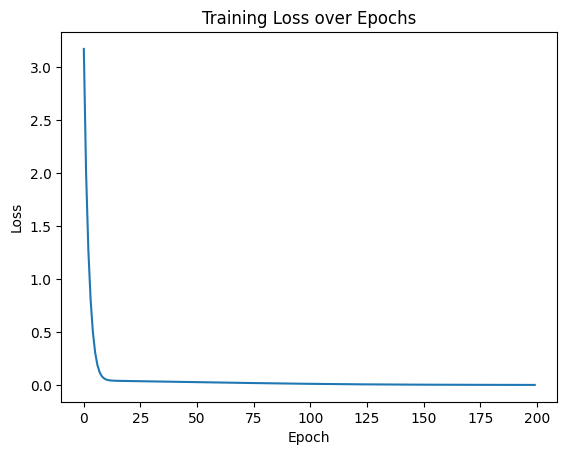

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# --- 1. Tiny toy input and target ---
x1 = np.array([[1.0]])
x2 = np.array([[2.0]])
y1 = np.array([[1.5]])
y2 = np.array([[2.0]])
h0 = np.array([[0.0]])

# --- 2. Initialize weights ---
W_xh = np.random.randn(1, 1) * 0.1
W_hh = np.random.randn(1, 1) * 0.1
b_h = np.zeros((1, 1))

W_hy = np.random.randn(1, 1) * 0.1
b_y = np.zeros((1, 1))

# --- 3. Training loop ---
lr = 0.1
epochs = 200
losses = []

for epoch in range(epochs):

    # Forward pass: t = 1
    a1 = W_xh @ x1 + W_hh @ h0 + b_h
    h1 = np.tanh(a1)
    yhat1 = W_hy @ h1 + b_y

    # Forward pass: t = 2
    a2 = W_xh @ x2 + W_hh @ h1 + b_h
    h2 = np.tanh(a2)
    yhat2 = W_hy @ h2 + b_y

    # Loss
    L1 = 0.5 * (yhat1 - y1)**2
    L2 = 0.5 * (yhat2 - y2)**2
    L = L1 + L2
    losses.append(float(L))

    # --- Backward pass ---
    # Output grads
    dy1 = yhat1 - y1
    dy2 = yhat2 - y2

    dW_hy = dy1 @ h1.T + dy2 @ h2.T
    db_y = dy1 + dy2

    # Hidden grads
    dh1 = W_hy.T @ dy1  # direct
    dh2 = W_hy.T @ dy2

    # Recurrence: h1 influences h2
    da2 = dh2 * (1 - np.tanh(a2)**2)
    da1_from_h2 = (W_hh.T @ da2) * (1 - np.tanh(a1)**2)

    da1 = dh1 * (1 - np.tanh(a1)**2) + da1_from_h2

    # Input-to-hidden and hidden-to-hidden
    dW_xh = da1 @ x1.T + da2 @ x2.T
    dW_hh = da1 @ h0.T + da2 @ h1.T
    db_h = da1 + da2

    # --- Update ---
    W_hy -= lr * dW_hy
    b_y  -= lr * db_y
    W_xh -= lr * dW_xh
    W_hh -= lr * dW_hh
    b_h  -= lr * db_h

    if epoch % 20 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch} | Loss: {L[0][0]:.6f}")

# --- 4. Final predictions ---
print("\nFinal Weights:")
print(f"W_xh: {W_xh}")
print(f"W_hh: {W_hh}")
print(f"W_hy: {W_hy}")
print(f"b_h: {b_h}")
print(f"b_y: {b_y}")

# Forward pass after training
a1 = W_xh @ x1 + W_hh @ h0 + b_h
h1 = np.tanh(a1)
yhat1 = W_hy @ h1 + b_y

a2 = W_xh @ x2 + W_hh @ h1 + b_h
h2 = np.tanh(a2)
yhat2 = W_hy @ h2 + b_y

print(f"\nInput x1: {x1}, Target y1: {y1}, Predicted y1: {yhat1}")
print(f"Input x2: {x2}, Target y2: {y2}, Predicted y2: {yhat2}")

# --- 5. Plot loss ---
plt.plot(losses)
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()